# Correlational Analysis

## Import Libraries

We begin by importing all required Python libraries:
- `numpy`, `pandas`: data handling
- `matplotlib`: visualization
- `gpflow`, `tensorflow`: Gaussian Process modeling
- Other utilities for preprocessing and evaluation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gpflow
from gpflow.utilities import print_summary

def to_float64(X):
    """
    Convert input data to float64.

    GPflow requires input data to be in float64 format.
    This function ensures compatibility and prevents dtype errors.
    """
    return np.asarray(X, dtype=np.float64)

## Data

In this step:
- Load PM2.5 dataset
- Convert timestamps
- Filter data by sensor and year
- Resample to uniform intervals
- Generate a complete time index

In [3]:
PMdata2025 = pd.read_csv("2025-PM25.csv")

PMdata2025['Timestamp'] = pd.to_datetime(PMdata2025['Timestamp'])
PMdata2025 = PMdata2025.sort_values('Timestamp')

PMdata2025.head()

,Unnamed: 0,Sensor_Name,Variable,Value,Timestamp,Flagged,Location_WKT,Sensor_Centroid_Longitude,Ground_Height_Above_Sea_Level,Sensor_Centroid_Latitude,Sensor_Height_Above_Ground,Broker_Name,Raw_ID
0,0,PER_AIRMON_MESH1922150,PM2.5,2.235,2025-01-01,False,POINT(-1.609327 54.991308),-1.609327,56.869999,54.991308,2.0,aq_mesh_api,79165
1,1,PER_AIRMON_MESH1919150,PM2.5,0.010,2025-01-01,False,POINT(-1.59605 54.902785),-1.596050,18.000000,54.902785,8.0,aq_mesh_api,79162
2,2,PER_AIRMON_MONITOR1135100,PM2.5,7.889,2025-01-01,False,POINT(-1.617676 54.979118),-1.617676,57.669998,54.979118,2.0,aq_mesh_api,79525
3,3,PER_AIRMON_MESH1957150,PM2.5,-0.378,2025-01-01,True,POINT(-1.704298 55.000748),-1.704298,114.000000,55.000748,2.0,aq_mesh_api,79194
4,4,PER_AIRMON_MONITOR914,PM2.5,3.305,2025-01-01,False,POINT(-1.619756 55.006886),-1.619756,62.590000,55.006886,2.0,aq_mesh_api,1726


In [5]:
"""
Filter and resample PM2.5 data for a specific sensor and year.

Steps:
1. Convert timestamp to datetime format
2. Filter dataset by sensor name
3. Restrict data to a specific year
4. Resample to uniform 15-minute intervals
5. Preserve missing values (no interpolation)

Why this step is important:
- Ensures consistent temporal resolution
- Removes irregular sampling issues
- Enables reliable rolling statistics
- Missing values are intentionally preserved to avoid introducing artificial bias
"""
def filter_and_resample_data(sensor_name, data, year):
    """
    Filters PM2.5 data for a specific sensor and year,
    then resamples it to uniform 15-minute intervals.

    Parameters:
    - sensor_name (str): Target sensor ID
    - data (DataFrame): Raw dataset
    - year (int): Target year

    Returns:
    - DataFrame: Cleaned and resampled dataset
    """

    # --- Convert timestamp ---
    data["Timestamp"] = pd.to_datetime(data["Timestamp"], errors="coerce")

    # --- Filter by sensor ---
    sensor_data = data[data["Sensor_Name"] == sensor_name].copy()

    # --- Define yearly range ---
    start_date = f"{year}-01-01 00:00:00"
    end_date   = f"{year}-12-31 23:59:59"

    # --- Filter by date ---
    filtered_data = sensor_data.loc[
        (sensor_data["Timestamp"] >= start_date) &
        (sensor_data["Timestamp"] <= end_date)
    ]

    # --- Set index for resampling ---
    filtered_data = filtered_data.set_index("Timestamp")

    # --- Resample to 15-minute intervals (no filling) ---
    # 15-minute resolution balances temporal detail and computational cost
    resampled_data = filtered_data.resample("15T").asfreq()

    # --- Reset index ---
    resampled_data = resampled_data.reset_index()

    return resampled_data

In [6]:
"""
Create a complete time index for the entire year
with 15-minute resolution.

Useful for:
- Detecting missing timestamps
- Aligning predictions
"""

start_date = "2025-01-01 00:00:00"
end_date   = "2025-12-31 23:59:00"

time_wholeyear_pm = pd.date_range(
    start=start_date,
    end=end_date,
    freq="15min"
)

## Data Processing and detrend

In [7]:
"""
Preprocess PM2.5 dataset and generate rolling statistics.

Steps:
1. Ensure datetime format
2. Sort data chronologically
3. Compute short-term smoothing
4. Estimate long-term trend (~1 day)
5. Detrend signal
6. Smooth detrended signal

Why preprocessing is important:
- Reduces high-frequency noise in PM2.5 observations
- Separates long-term trends from short-term fluctuations
- Improves Gaussian Process model stability and predictive performance

Notes:
- 15-minute interval data
- 96 points ≈ 1 day → use 97 (centered window)
"""
def preprocess_sensor(df_sensor):
    df = df_sensor.copy()
    
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.sort_values("Timestamp").reset_index(drop=True)
    df = df.set_index("Timestamp")

    # Rolling Statistics (Short-term)
    df["Rolling Mean"] = df["Value"].rolling(window=5, min_periods=1, center=True).mean()
    df["Rolling Std"] = df["Value"].rolling(window=5, min_periods=1, center=True).std()
    df["Rolling Median"] = df["Value"].rolling(window=5, min_periods=1, center=True).median()

    # Long-term Trend (Detrending)
    df["Rolling Mean (1D)"] = df["Value"].rolling(window=97, min_periods=1, center=True).mean()
    # Remove long-term trend to isolate short-term variability
    df["Detrended"] = df["Value"] - df["Rolling Mean (1D)"]

    # Smoothed Detrended Signal
    df["Rolling Detrended"] = df["Detrended"].rolling(window=5, min_periods=1, center=True).mean()

    return df.reset_index()

In [ ]:
# Process data

sensor_names = PMdata2025["Sensor_Name"].unique()

sensor_processed = {}

for sensor in sensor_names:
    df_sensor = filter_and_resample_data(sensor, PMdata2025, 2025)

    # Step 2: align to full timeline
    df_sensor = df_sensor.set_index("Timestamp").reindex(time_wholeyear_pm).reset_index()
    df_sensor = df_sensor.rename(columns={"index": "Timestamp"})

    # Step 3: preprocess
    df_sensor = preprocess_sensor(df_sensor)

    sensor_processed[sensor] = df_sensor

sensor_processed

C:\Users\c3040922\AppData\Local\Temp\ipykernel_20524\3901877074.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_data = filtered_data.resample("15T").asfreq()
C:\Users\c3040922\AppData\Local\Temp\ipykernel_20524\3901877074.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_data = filtered_data.resample("15T").asfreq()
C:\Users\c3040922\AppData\Local\Temp\ipykernel_20524\3901877074.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_data = filtered_data.resample("15T").asfreq()
C:\Users\c3040922\AppData\Local\Temp\ipykernel_20524\3901877074.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_data = filtered_data.resample("15T").asfreq()
C:\Users\c3040922\AppData\Local\Temp\ipykernel_20524\3901877074.py:52: FutureWarning

In [9]:
# Correlational dataframe

df_corr = pd.concat(
    [
        df.set_index("Timestamp")["Detrended"].rename(sensor)
        for sensor, df in sensor_processed.items()
    ],
    axis=1
)

corr_matrix = df_corr.corr(min_periods=100)

c:\ProgramData\anaconda3\envs\gpflow_env\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\ProgramData\anaconda3\envs\gpflow_env\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


Text(120.7222222222222, 0.5, 'Sensors')

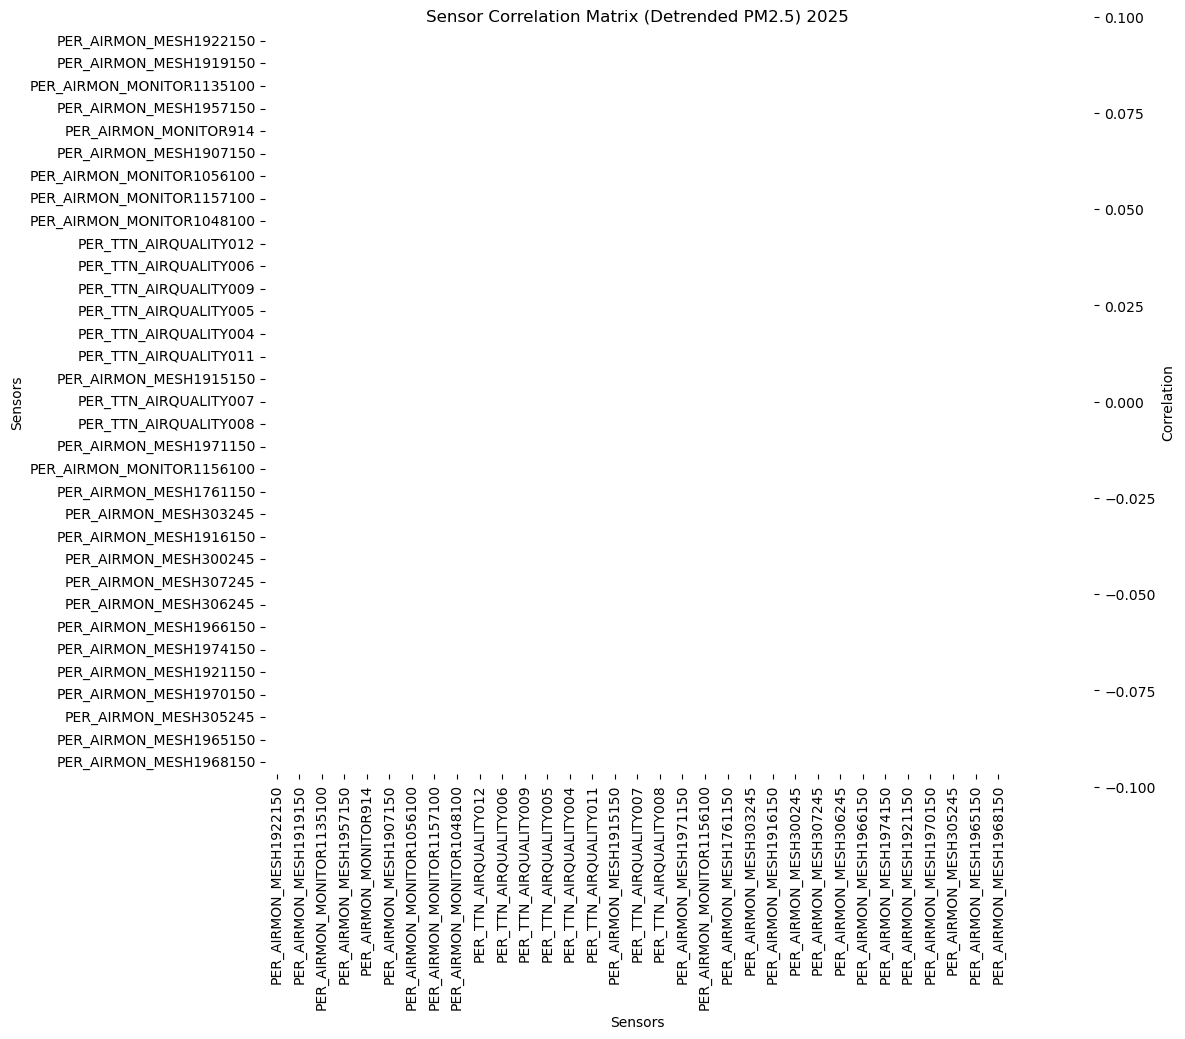

In [10]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"},
)

plt.title("Sensor Correlation Matrix (Detrended PM2.5) 2025")
plt.xlabel("Sensors")
plt.ylabel("Sensors")

In [ ]:
corr_clean = corr_matrix.fillna(0)

g = sns.clustermap(
    corr_clean,
    cmap="coolwarm",
    center=0,
    figsize=(12, 12)
)

g.fig.suptitle("Sensor Correlation Matrix (Detrended PM2.5) 2025")

In [ ]:
sensor_coords = (
    PMdata2018[["Sensor Name", "Sensor Centroid Latitude", "Sensor Centroid Longitude"]]
    .drop_duplicates()
    .set_index("Sensor Name")
    .loc[sensor_names]
)

def haversine_matrix(coords):
    """
    coords: array of shape (n_sensors, 2) in degrees [lat, lon]
    returns: distance matrix in km
    """
    
    coords = np.radians(coords)
    lat = coords[:, 0][:, None]
    lon = coords[:, 1][:, None]

    dlat = lat - lat.T
    dlon = lon - lon.T

    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    R = 6371  # Earth radius in km
    return R * c

coords = sensor_coords[[
    "Sensor Centroid Latitude",
    "Sensor Centroid Longitude"
]].values

dist_matrix = haversine_matrix(coords)

corr_vals = corr_matrix.values[np.triu_indices(len(sensor_names), 1)]
dist_vals = dist_matrix[np.triu_indices(len(sensor_names), 1)]

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(dist_vals, corr_vals, alpha=0.4)

plt.xlabel("Distance (km)")
plt.ylabel("Correlation (Detrended PM2.5)")
plt.title("Spatial decay of PM2.5 correlation 2025")

plt.show()